In [1]:
# CELL 1: Setup, Imports & Data Loading

# --- Core Libraries & Setup ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import chi2_contingency
from tab_transformer_pytorch import TabTransformer
from pathlib import Path
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
try:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# --- Global Settings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 8)})

# --- Load Data ---
master_df = pd.read_csv('GSE164641_master_dataframe.csv', index_col=0)
y = master_df['target'].map({'High': 1, 'Average': 0})
X = master_df.drop(columns=['target'])
print("Data loaded successfully.")

Data loaded successfully.


C:\Users\27694\AppData\Local\Temp\ipykernel_21092\1415093348.py:40: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  master_df = pd.read_csv('GSE164641_master_dataframe.csv', index_col=0)


In [2]:
# CELL 2: Define All Helper Functions

def process_fold_features(X_train, y_train, X_test):
    """Encapsulates all feature engineering for a single fold."""
    # (This function is a condensed version of our previous feature engineering cell)
    known_cat_cols = ['age', 'age_of_menarche', 'menopausal_status', 'brca1', 'brca2', 'blood_relatives_cancer', 'race',
                      'hispanic', 'bmi', 'ever_pregnant', 'tyrer_cuzick_score']
    cat_cols = [col for col in known_cat_cols if col in X_train.columns]
    X_train_cat = X_train[cat_cols].copy();
    X_test_cat = X_test[cat_cols].copy()
    if 'tyrer_cuzick_score' in X_train_cat.columns:
        for df in [X_train_cat, X_test_cat]: df.drop(columns=['tyrer_cuzick_score'], inplace=True)

    def clean_numeric_cols(df):
        for col in ['age', 'age_of_menarche', 'bmi']:
            if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce')
        return df

    X_train_cat = clean_numeric_cols(X_train_cat);
    X_test_cat = clean_numeric_cols(X_test_cat)
    imputation_values = {
        col: X_train_cat[col].median() if pd.api.types.is_numeric_dtype(X_train_cat[col]) else X_train_cat[col].mode()[
            0] for col in X_train_cat.columns}
    for col, value in imputation_values.items():
        X_train_cat[col].fillna(value, inplace=True);
        X_test_cat[col].fillna(value, inplace=True)
    bmi_bins = [0, 18.5, 25, 30, float('inf')];
    bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    _, menarche_bins = pd.qcut(X_train_cat['age_of_menarche'], q=3, retbins=True, duplicates='drop');
    menarche_labels = ['Early', 'Normal', 'Late']
    if len(menarche_bins) - 1 != len(menarche_labels): menarche_labels = [f'g{k + 1}' for k in
                                                                          range(len(menarche_bins) - 1)]

    _, age_bins = pd.qcut(X_train_cat['age'], q=5, retbins=True, duplicates='drop')
    age_labels = [f'a{k + 1}' for k in range(len(age_bins) - 1)]

    for df in [X_train_cat, X_test_cat]:
        df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)
        df['bmi_category'] = pd.cut(df['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)
        df['menarche_category'] = pd.cut(df['age_of_menarche'], bins=menarche_bins, labels=menarche_labels,
                                         include_lowest=True)
        df.drop(columns=['age', 'bmi', 'age_of_menarche'], inplace=True)
    # selected_categorical_features = [col for col in X_train_cat.columns if chi2_contingency(pd.crosstab(X_train_cat[col].astype('category'), y_train))[1] < 0.05]
    candidate_for_chi2 = [c for c in X_train_cat.columns if c.endswith('_category') or c in
                          ['menopausal_status', 'brca1', 'brca2', 'blood_relatives_cancer', 'race', 'hispanic',
                           'ever_pregnant']]
    selected_categorical_features = [
        col for col in candidate_for_chi2
        if chi2_contingency(pd.crosstab(X_train_cat[col].astype('category'), y_train))[1] < 0.05
    ]

    gene_cols = X_train.columns.drop(cat_cols)
    X_train_cont_raw = X_train[gene_cols].copy();
    X_test_cont_raw = X_test[gene_cols].copy()
    X_train_cont_raw = X_train_cont_raw.T.groupby(level=0).sum().T
    all_gene_columns = X_train_cont_raw.columns
    X_test_cont_raw = X_test_cont_raw.T.groupby(level=0).sum().T.reindex(columns=all_gene_columns, fill_value=0)

    samples_df = pd.DataFrame({'condition': y_train})
    dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition');
    dds.deseq2()
    stat_res = DeseqStats(dds, contrast=['condition', 1, 0]);
    stat_res.summary();
    results_df = stat_res.results_df
    significant_genes = results_df[
        (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1.0)].index.tolist()

    return X_train_cat, X_test_cat, selected_categorical_features, X_train_cont_raw, X_test_cont_raw, significant_genes


def train_tt_in_cv(X_cat_train, X_cont_train, y_train, X_cat_test, X_cont_test, cat_cardinalities):
    """A simplified training function for Tab-Transformer inside a CV loop."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    model = TabTransformer(categories=cat_cardinalities, num_continuous=X_cont_train.shape[1], dim=32, dim_out=2,
                           depth=6, heads=8).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)  # ; criterion = nn.CrossEntropyLoss()
    pos = float(y_train.sum());
    neg = float(len(y_train) - pos)
    w = torch.tensor([neg / (pos + neg), pos / (pos + neg)], dtype=torch.float32)
    criterion = nn.CrossEntropyLoss(weight=w.to(device))
    # In CV, we typically train for a fixed number of epochs without a separate validation set.
    for epoch in range(50):
        model.train();
        optimizer.zero_grad()
        output = model(X_cat_train.to(device), X_cont_train.to(device));
        loss = criterion(output, y_train_tensor.to(device))
        loss.backward();
        optimizer.step()
    model.eval()
    with torch.no_grad():
        test_output = model(X_cat_test.to(device), X_cont_test.to(device))
        y_pred_proba = torch.softmax(test_output, dim=1).cpu().numpy()[:, 1]
    return y_pred_proba


print("Helper functions defined.")

Helper functions defined.


In [3]:
# CELL 3: The Main Cross-Validation Loop

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Create a dictionary to store results (AUC scores and TPRs for plotting)
results = {'AUCs': {}, 'TPRs': {}}
mean_fpr = np.linspace(0, 1, 100)  # Common x-axis for ROC curves
cr_macro = {}
cr_weighted = {}

# --- Start the Loop ---
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n========== FOLD {i + 1}/{N_SPLITS} ========== ")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # --- 1. Perform feature engineering for the current fold ---
    X_train_cat, X_test_cat, sel_cat_feats, X_train_cont_raw, X_test_cont_raw, sig_genes = process_fold_features(
        X_train, y_train, X_test)

    if not sig_genes:  # correct1
        print(f"Fold {i + 1}: no significant genes; continuous stream will be empty this fold.")
        # print(f"Fold {i+1} skipped due to no significant genes found.")
        # continue

    # --- 2. Prepare final data subsets for this fold ---
    # Scikit-learn data
    scaler = StandardScaler();
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
    X_train_cont_final = pd.DataFrame(scaler.fit_transform(np.log1p(X_train_cont_raw[sig_genes])), index=X_train.index,
                                      columns=sig_genes)
    X_test_cont_final = pd.DataFrame(scaler.transform(np.log1p(X_test_cont_raw[sig_genes])), index=X_test.index,
                                     columns=sig_genes)
    X_train_cat_final = pd.DataFrame(onehot.fit_transform(X_train_cat[sel_cat_feats]), index=X_train.index,
                                     columns=onehot.get_feature_names_out())
    X_test_cat_final = pd.DataFrame(onehot.transform(X_test_cat[sel_cat_feats]), index=X_test.index,
                                    columns=onehot.get_feature_names_out())
    X_train_comb = pd.concat([X_train_cat_final, X_train_cont_final], axis=1);
    X_test_comb = pd.concat([X_test_cat_final, X_test_cont_final], axis=1)

    # Tab-Transformer data
    ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1);
    ordinal.fit(X_train_cat[sel_cat_feats])
    X_train_cat_ord = torch.tensor(ordinal.transform(X_train_cat[sel_cat_feats]), dtype=torch.long)
    X_test_cat_ord = torch.tensor(ordinal.transform(X_test_cat[sel_cat_feats]), dtype=torch.long)
    cat_cards = [len(cats) for cats in ordinal.categories_]
    X_train_cont_tensor = torch.tensor(X_train_cont_final.values, dtype=torch.float32)
    X_test_cont_tensor = torch.tensor(X_test_cont_final.values, dtype=torch.float32)

    # --- 3. Run all experiments for this fold ---
    has_cont = (len(sig_genes) > 0)
    has_cat = (len(sel_cat_feats) > 0)

    models_to_run = {}
    if has_cont:
        models_to_run['TT_cont'] = lambda: train_tt_in_cv(
            torch.empty(len(X_train), 0, dtype=torch.long), X_train_cont_tensor, y_train,
            torch.empty(len(X_test), 0, dtype=torch.long), X_test_cont_tensor, [])
        models_to_run['RF_cont'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LR_cont'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LASSO_cont'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

    if has_cat:
        models_to_run['TT_cat'] = lambda: train_tt_in_cv(
            X_train_cat_ord, torch.empty(len(X_train), 0), y_train, X_test_cat_ord, torch.empty(len(X_test), 0),
            cat_cards)

    if has_cat or has_cont:
        models_to_run['TT_comb'] = lambda: train_tt_in_cv(
            X_train_cat_ord if has_cat else torch.empty(len(X_train), 0, dtype=torch.long),
            X_train_cont_tensor if has_cont else torch.empty(len(X_train), 0),
            y_train,
            X_test_cat_ord if has_cat else torch.empty(len(X_test), 0, dtype=torch.long),
            X_test_cont_tensor if has_cont else torch.empty(len(X_test), 0),
            cat_cards if has_cat else []
        )
        models_to_run['RF_comb'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LR_comb'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LASSO_comb'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

    for name, train_eval_func in models_to_run.items():
        if name not in results['AUCs']:  # Initialize lists on first fold
            results['AUCs'][name] = []
            results['TPRs'][name] = []

        y_proba = train_eval_func()
        auc_score = roc_auc_score(y_test, y_proba)
        results['AUCs'][name].append(auc_score)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        results['TPRs'][name].append(interp_tpr)
        print(f"  {name}: AUC = {auc_score:.4f}")
        y_pred = (y_proba >= 0.5).astype(int)
        cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        if name not in cr_macro:
            cr_macro[name] = []
        if name not in cr_weighted:
            cr_weighted[name] = []

        cr_macro[name].append([
            cr["macro avg"]["precision"],
            cr["macro avg"]["recall"],
            cr["macro avg"]["f1-score"],
        ])
        cr_weighted[name].append([
            cr["weighted avg"]["precision"],
            cr["weighted avg"]["recall"],
            cr["weighted avg"]["f1-score"],
        ])

print("\n========== CROSS-VALIDATION COMPLETE ==========")


========== FOLD 1/5 ========== 


C:\Users\27694\AppData\Local\Temp\ipykernel_21092\2959847219.py:60: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition');
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.30 seconds.

Fitting dispersions...
... done in 2.83 seconds.

Fitting dispersion trend curve...
... done in 0.58 seconds.

Fitting MAP dispersions...
... done in 3.50 seconds.

Fitting LFCs...
... done in 2.46 seconds.

Calculating cook's distance...
... done in 0.44 seconds.

Replacing 1350 outlier genes.

Fitting dispersions...
... done in 0.43 seconds.

Fitting MAP dispersions...
... done in 0.44 seconds.

Fitting LFCs...
... done in 0.43 seconds.

Running Wald tests...
... done in 1.96 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
100128338   321.462292        0.594787  0.264652  2.247434  0.024612  0.100144
100128818     2.440967        0.478222  0.289926  1.649465  0.099052  0.248583
100129503    15.071942        0.039216  0.123132  0.318490  0.750113  0.858609
100131096   223.092416       -0.210471  0.085971 -2.448151  0.014359  0.070780
100133331   258.928122       -0.186145  0.147208 -1.264504  0.206049  0.393853
...                ...             ...       ...       ...       ...       ...
ZYG11A       46.671474        0.634518  0.248868  2.549613  0.010784  0.059190
ZYG11B     1233.545231       -0.090128  0.076321 -1.180898  0.237643  0.430184
ZYX        1953.701005       -0.151181  0.079419 -1.903582  0.056965  0.173394
ZZEF1      1897.152065       -0.075853  0.063267 -1.198933  0.230554  0.421857
ZZZ3       1399.085578        0.188318  0.051312  3.670082  0.000242  0.0059

...

Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
100128338   333.571976        0.628791  0.274340  2.292016  0.021905  0.102145
100128818     1.998201        0.459862  0.260874  1.762777  0.077938  0.225191
100129503    14.791631        0.313553  0.113248  2.768727  0.005628  0.045233
100131096   236.426731       -0.225345  0.087188 -2.584595  0.009749  0.062676
100133331   262.233835       -0.043619  0.137342 -0.317597  0.750791  0.868089
...                ...             ...       ...       ...       ...       ...
ZYG11A       46.062433        0.503184  0.261133  1.926931  0.053988  0.179016
ZYG11B     1280.479075       -0.057885  0.073710 -0.785310  0.432272  0.635539
ZYX        1949.555347       -0.135504  0.079312 -1.708487  0.087546  0.241912
ZZEF1      1954.167075       -0.055322  0.074542 -0.742152  0.457995  0.657569
ZZZ3       1422.606041        0.174885  0.055350  3.159625  0.001580  0.0213

C:\Users\27694\AppData\Local\Temp\ipykernel_21092\2959847219.py:60: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition');
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.27 seconds.

Fitting dispersions...
... done in 3.24 seconds.

Fitting dispersion trend curve...
... done in 0.61 seconds.

Fitting MAP dispersions...
... done in 3.65 seconds.

Fitting LFCs...
... done in 2.61 seconds.

Calculating cook's distance...
... done in 0.47 seconds.

Replacing 2300 outlier genes.

Fitting dispersions...
... done in 0.47 seconds.

Fitting MAP dispersions...
... done in 0.46 seconds.

Fitting LFCs...
... done in 0.59 seconds.

Running Wald tests...
... done in 1.99 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
100128338   329.684262        0.697368  0.272508  2.559076  0.010495  0.054647
100128818     2.439483        0.310047  0.298877  1.037375  0.299561  0.475799
100129503    14.753043        0.231963  0.124992  1.855830  0.063478  0.170767
100131096   234.785897       -0.161184  0.084749 -1.901898  0.057185  0.159478
100133331   272.043934        0.007849  0.144297  0.054392  0.956623  0.977051
...                ...             ...       ...       ...       ...       ...
ZYG11A       45.393915        0.518493  0.253909  2.042041  0.041147  0.128924
ZYG11B     1265.241635       -0.164235  0.074623 -2.200867  0.027745  0.099900
ZYX        1929.702642       -0.039657  0.078448 -0.505514  0.613198  0.752596
ZZEF1      1945.328141       -0.060925  0.073882 -0.824626  0.409584  0.581496
ZZZ3       1395.091435        0.178116  0.055036  3.236353  0.001211  0.0158

In [4]:
summary_data = []

# Loop through the dictionary of AUC scores from the CV results
for name, auc_list in results['AUCs'].items():
    # Calculate the mean and standard deviation for each experiment's list of AUCs
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    
    summary_data.append({
        'Experiment': name.replace("_", " ").title(), # Make the name prettier
        'Mean AUC': mean_auc,
        'Std Dev (±)': std_auc
    })

# Create and sort the DataFrame for better readability
summary_cv_df = pd.DataFrame(summary_data).set_index('Experiment').sort_values(by='Mean AUC', ascending=False)

print("\n--- Final Cross-Validation Performance Summary ---")
print("Metrics are reported as Mean ± Standard Deviation over 5 folds.")

# Display the styled table
display(summary_cv_df.style
    .format({'Mean AUC': '{:.3f}', 'Std Dev (±)': '{:.3f}'})
    .background_gradient(cmap='Greens', subset=['Mean AUC'])
    .bar(subset=['Std Dev (±)'], color='#d4edda', align='zero')
    .set_properties(**{'border': '1px solid #dee2e6', 'padding': '8px'})
    .set_table_styles([{'selector': 'thead th', 'props': [('background-color', '#f8f9fa'), ('border-bottom', '2px solid #dee2e6')]}])
)

summary_cv_path = OUT_DIR / "cv_auc_summary.csv"
summary_cv_df.to_csv(summary_cv_path, index=True)
print(f"Saved CV AUC summary to: {summary_cv_path}")


--- Final Cross-Validation Performance Summary ---
Metrics are reported as Mean ± Standard Deviation over 5 folds.


,Mean AUC,Std Dev (±)
Experiment,,
Tt Comb,0.904,0.051
Tt Cat,0.885,0.021
Lasso Comb,0.817,0.032
Rf Comb,0.816,0.056
Lr Comb,0.686,0.077
Rf Cont,0.650,0.071
Tt Cont,0.639,0.086
Lasso Cont,0.606,0.038
Lr Cont,0.591,0.089


Saved CV AUC summary to: output\cv_auc_summary.csv


In [5]:
def _cr_store_to_df(store: dict, label: str) -> pd.DataFrame:
    rows = []
    for name, arr in store.items():
        A = np.asarray(arr, dtype=float)  # shape (n_folds, 3)
        mu = A.mean(axis=0)
        sd = A.std(axis=0)
        rows.append([
            name,
            mu[0], sd[0],
            mu[1], sd[1],
            mu[2], sd[2],
        ])
    return pd.DataFrame(rows, columns=[
        "Model",
        f"{label} Precision (mean)", f"{label} Precision (std)",
        f"{label} Recall (mean)",    f"{label} Recall (std)",
        f"{label} F1 (mean)",        f"{label} F1 (std)",
    ]).sort_values("Model").reset_index(drop=True)

macro_df = _cr_store_to_df(cr_macro, "Macro")
weighted_df = _cr_store_to_df(cr_weighted, "Weighted")

print("\n--- Classification Report (Macro avg) — 5-fold mean ± std ---")
display(macro_df)
print("\n--- Classification Report (Weighted avg) — 5-fold mean ± std ---")
display(weighted_df)

macro_path = OUT_DIR / "cv_classification_report_macro.csv"
weighted_path = OUT_DIR / "cv_classification_report_weighted.csv"
macro_df.to_csv(macro_path, index=False)
weighted_df.to_csv(weighted_path, index=False)
print(f"Saved CR tables to:\n- {macro_path}\n- {weighted_path}")


--- Classification Report (Macro avg) — 5-fold mean ± std ---


,Model,Macro Precision (mean),Macro Precision (std),Macro Recall (mean),Macro Recall (std),Macro F1 (mean),Macro F1 (std)
0,LASSO_comb,0.743729,0.066726,0.741278,0.062656,0.739055,0.063463
1,LASSO_cont,0.569580,0.023236,0.562885,0.015085,0.560843,0.015341
2,LR_comb,0.624302,0.054875,0.614308,0.060148,0.611453,0.059001
3,LR_cont,0.543553,0.039713,0.538235,0.032398,0.536156,0.030820
4,RF_comb,0.771706,0.027178,0.737352,0.026541,0.742086,0.026030
5,RF_cont,0.594613,0.072067,0.576034,0.057195,0.571668,0.057887
6,TT_cat,0.809684,0.021348,0.801594,0.029285,0.802810,0.027350
7,TT_comb,0.834111,0.028227,0.823821,0.040958,0.824743,0.035869
8,TT_cont,0.584227,0.070933,0.578946,0.068737,0.574707,0.073931



--- Classification Report (Weighted avg) — 5-fold mean ± std ---


,Model,Weighted Precision (mean),Weighted Precision (std),Weighted Recall (mean),Weighted Recall (std),Weighted F1 (mean),Weighted F1 (std)
0,LASSO_comb,0.754792,0.062001,0.748791,0.061294,0.748549,0.060853
1,LASSO_cont,0.584546,0.021015,0.587909,0.031338,0.581298,0.022360
2,LR_comb,0.636749,0.054927,0.641679,0.050103,0.632081,0.053159
3,LR_cont,0.559974,0.037385,0.561024,0.044399,0.556179,0.035752
4,RF_comb,0.771095,0.022525,0.764723,0.019392,0.756812,0.022332
5,RF_cont,0.605894,0.065572,0.609246,0.062433,0.595491,0.056819
6,TT_cat,0.814993,0.021380,0.812802,0.023982,0.811337,0.025311
7,TT_comb,0.838601,0.031374,0.834424,0.029968,0.832644,0.032213
8,TT_cont,0.599103,0.066118,0.609957,0.060501,0.598231,0.066019


Saved CR tables to:
- output\cv_classification_report_macro.csv
- output\cv_classification_report_weighted.csv



--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (with Std Dev) ---
Saved figure to: output\cv_roc_only_continuous.png


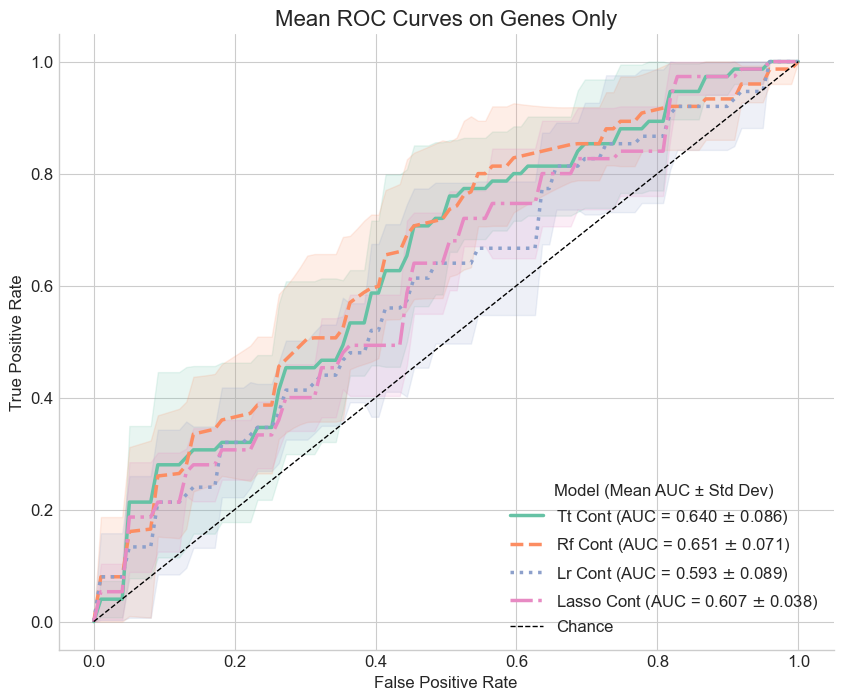


--- Generating Plot 2: Tab-Transformer Ablation Study (with Std Dev) ---
Saved figure to: output\cv_roc_tt_internal.png


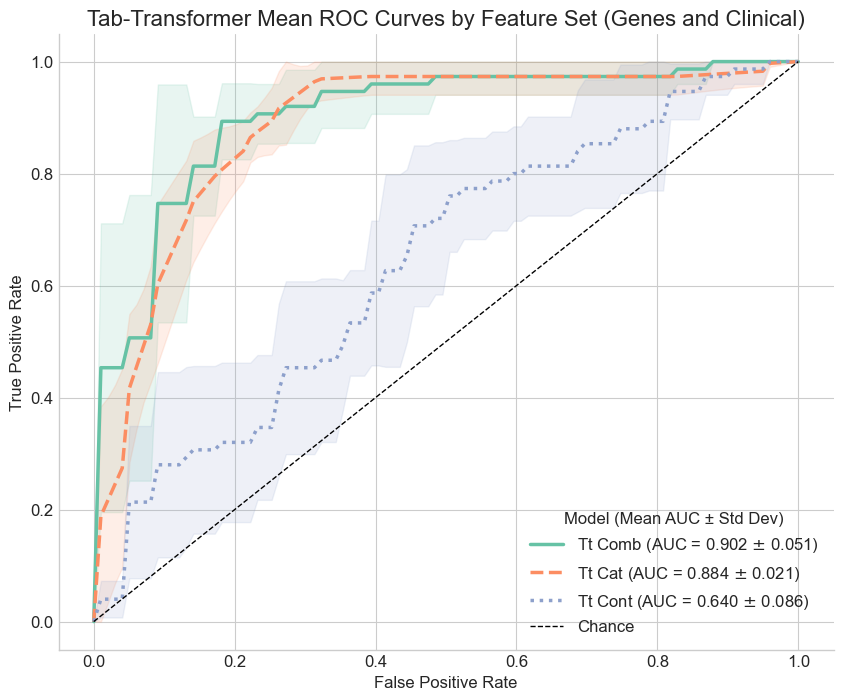


--- Generating Plot 3: Final Model Showdown on Combined Features (Genes and Clinical) (with Std Dev) ---
Saved figure to: output\cv_roc_combined.png


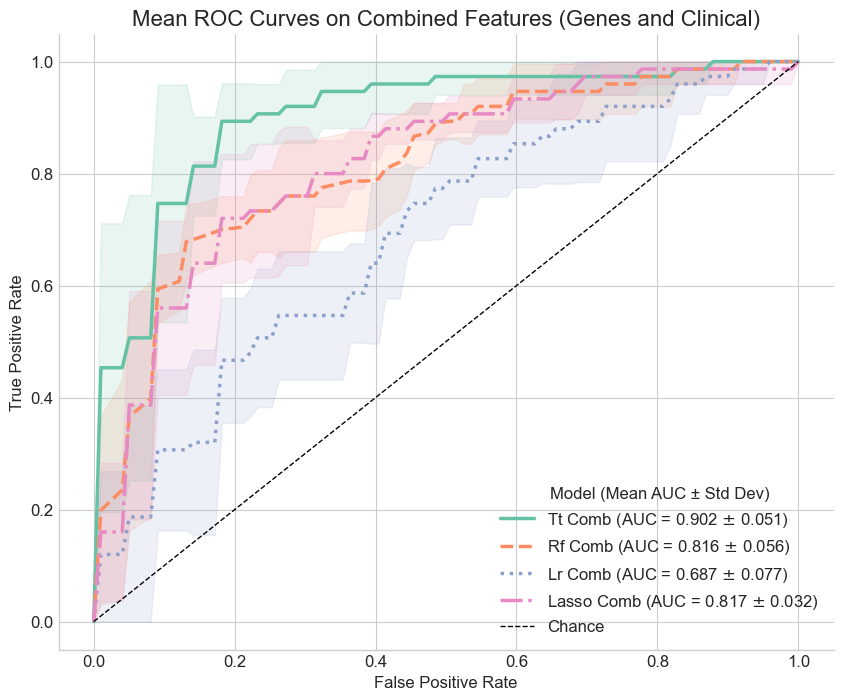

In [6]:
# CELL 5 (Revised): Generate Final Comparative Plots with Standard Deviation Bands

def plot_mean_roc_curves_with_std(results_tprs, results_aucs, model_keys, title, save_path=None):
    """
    Helper function to plot multiple mean ROC curves from CV results,
    including a shaded standard deviation band for each curve.
    """
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('Set2', n_colors=len(model_keys))
    linestyles = ['-', '--', ':', '-.']
    
    # --- Loop through each model to plot ---
    for i, key in enumerate(model_keys):
        # Check if results for this model exist
        if key not in results_tprs or not results_tprs[key]:
            print(f"Warning: No results found for '{key}'. Skipping this curve.")
            continue
            
        # --- Calculations for the current model ---
        tpr_array = np.array(results_tprs[key])
        mean_tprs = tpr_array.mean(axis=0)
        mean_tprs[-1] = 1.0 # Ensure the curve goes to the top-right corner
        
        # Calculate mean AUC and std of AUCs
        mean_auc = auc(mean_fpr, mean_tprs)
        std_auc = np.std(results_aucs[key])
        
        # Calculate standard deviation of TPRs for the shaded band
        std_tpr = tpr_array.std(axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tpr, 1)
        tprs_lower = np.maximum(mean_tprs - std_tpr, 0)
        
        # --- Plotting for the current model ---
        # Plot the mean ROC curve
        plt.plot(mean_fpr, mean_tprs, color=colors[i], linestyle=linestyles[i % len(linestyles)], lw=2.5,
                 label=f'{key.replace("_", " ").title()} (AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f})')
        
        # Plot the shaded standard deviation band with high transparency
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.15)

    # --- Finalize the plot ---
    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    plt.title(title, fontsize=16)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", title="Model (Mean AUC ± Std Dev)"); plt.grid(True); sns.despine()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()

# ==============================================================================
# Generate the three requested plots using the new function
# ==============================================================================

# --- Plot 1: Continuous Features Only ---
print("\n--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (with Std Dev) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'], 
    results['AUCs'],
    ['TT_cont', 'RF_cont', 'LR_cont', 'LASSO_cont'],
    "Mean ROC Curves on Genes Only",
    save_path=OUT_DIR / "cv_roc_only_continuous.png"
)

# --- Plot 2: Tab-Transformer Ablation Study ---
print("\n--- Generating Plot 2: Tab-Transformer Ablation Study (with Std Dev) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'], 
    results['AUCs'],
    ['TT_comb', 'TT_cat', 'TT_cont'],
    "Tab-Transformer Mean ROC Curves by Feature Set (Genes and Clinical)",
    save_path=OUT_DIR / "cv_roc_tt_internal.png"
)

# --- Plot 3: Combined Features Showdown ---
print("\n--- Generating Plot 3: Final Model Showdown on Combined Features (Genes and Clinical) (with Std Dev) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'], 
    results['AUCs'],
    ['TT_comb', 'RF_comb', 'LR_comb', 'LASSO_comb'],
    "Mean ROC Curves on Combined Features (Genes and Clinical)",
    save_path=OUT_DIR / "cv_roc_combined.png"
)